# 01 — Flickr8k Dataset & Preprocessing from Scratch
## Image Captioning Final Project


### الزامات متن پروژه که در این Notebook پیاده‌سازی می‌شوند
- نگاشت صحیح تصاویر و کپشن‌ها
- Resize تصاویر
- Normalization متناسب با مدل pretrained
- lowercase و پاک‌سازی متن
- Tokenization
- ساخت Vocabulary
- تعریف `<START>`, `<END>`, `<PAD>` و `<UNK>`
- تقسیم Train / Validation / Test با seed ثابت
- گرید واقعی 5×5 از batch آموزشی

### تصمیم‌های پیاده‌سازی ما
- Split در سطح **image** برای جلوگیری از leakage
- Vocabulary و MAX_LEN فقط از Train
- حفظ قطعی `<END>` هنگام truncation
- استفاده از ResNet50 ImageNet-V2
- ذخیره اختیاری ویژگی‌های فضایی `(49, 2048)` برای استفاده یکسان در LSTM و Transformer

## 1. Imports and reproducibility

In [1]:
import os, re, json, time, math, random, string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
import torchvision.transforms as T

import h5py
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Configuration

In [2]:
class CFG:
    SEED = 42

    INPUT_ROOT = "/kaggle/input/datasets/adityajn105/flickr8k"
    IMAGES_DIR = None
    CAPTION_FILE = None

    TRAIN_RATIO = 0.80
    VAL_RATIO = 0.10
    TEST_RATIO = 0.10

    MIN_WORD_FREQ = 5
    MAX_VOCAB_SIZE = 10000
    LEN_PERCENTILE = 95
    MIN_MAX_LEN = 8
    HARD_MAX_LEN = 35

    EXTRACT_FEATURES = True
    FEATURE_DTYPE = "float16"
    FEATURE_BATCH_SIZE = 64
    FEATURE_NUM_WORKERS = 2

    OUTPUT_DIR = "/kaggle/working/preprocessed"

set_seed(CFG.SEED)
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

assert abs(CFG.TRAIN_RATIO + CFG.VAL_RATIO + CFG.TEST_RATIO - 1.0) < 1e-8
print("Output:", CFG.OUTPUT_DIR)

Output: /kaggle/working/preprocessed


## 3. Find and parse the raw Flickr8k caption file

این loader سه فرمت رایج Flickr8k را پشتیبانی می‌کند:
- `image,caption`
- `image.jpg#0<TAB>caption`
- فایل‌های pipe-separated

In [3]:
def parse_caption_file(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        preview = [f.readline() for _ in range(5)]

    first = next((x for x in preview if x.strip()), "")

    # CSV: image,caption
    if "," in first and "image" in first.lower():
        rows = []
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            _ = f.readline()
            for line in f:
                line = line.rstrip("\n")
                if not line or "," not in line:
                    continue
                image, caption = line.split(",", 1)
                rows.append((image.strip(), caption.strip()))
        return pd.DataFrame(rows, columns=["image", "caption"])

    # Classic tokens: image.jpg#0<TAB>caption
    if "\t" in first:
        rows = []
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.rstrip("\n")
                if not line or "\t" not in line:
                    continue
                image_part, caption = line.split("\t", 1)
                image = image_part.split("#")[0].strip()
                rows.append((image, caption.strip()))
        if rows:
            return pd.DataFrame(rows, columns=["image", "caption"])

    # Pipe-separated
    if "|" in first:
        tmp = pd.read_csv(path, sep="|", engine="python", on_bad_lines="skip")
        tmp.columns = [str(c).strip().lower() for c in tmp.columns]
        image_cols = [c for c in tmp.columns if "image" in c]
        caption_cols = [c for c in tmp.columns if "caption" in c or "comment" in c]
        if image_cols and caption_cols:
            out = tmp[[image_cols[0], caption_cols[0]]].copy()
            out.columns = ["image", "caption"]
            return out

    raise ValueError(f"Unsupported caption format: {path}")

def discover_caption_file(root):
    candidates = []

    for dirpath, _, filenames in os.walk(root):
        for filename in filenames:
            low = filename.lower()

            if not low.endswith((".txt", ".csv", ".token")):
                continue
            if not any(k in low for k in ("caption", "token", "result")):
                continue

            path = os.path.join(dirpath, filename)

            try:
                candidate = parse_caption_file(path)
                n_rows = len(candidate)
                n_images = candidate["image"].nunique()

                score = 0
                if n_rows >= 30000:
                    score += 100
                if 7000 <= n_images <= 9000:
                    score += 100
                if "caption" in low:
                    score += 20
                if "token" in low:
                    score += 10

                candidates.append((score, n_rows, n_images, path))
            except Exception:
                pass

    if not candidates:
        return None, []

    candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
    return candidates[0][3], candidates

if CFG.CAPTION_FILE:
    CAPTION_FILE = CFG.CAPTION_FILE
    caption_candidates = []
else:
    CAPTION_FILE, caption_candidates = discover_caption_file(CFG.INPUT_ROOT)

assert CAPTION_FILE is not None, (
    "Flickr8k captions were not found. Attach the raw dataset or set CFG.CAPTION_FILE."
)

print("Selected caption file:", CAPTION_FILE)

for score, rows, images, p in caption_candidates[:5]:
    print(f"score={score:3d} rows={rows:6d} images={images:5d} | {p}")

Selected caption file: /kaggle/input/datasets/adityajn105/flickr8k/captions.txt
score=220 rows= 40455 images= 8091 | /kaggle/input/datasets/adityajn105/flickr8k/captions.txt


## 4. Load and audit raw captions

In [4]:
raw_df = parse_caption_file(CAPTION_FILE)
raw_df = raw_df.dropna(subset=["image", "caption"]).copy()

raw_df["image"] = raw_df["image"].astype(str).map(os.path.basename).str.strip()
raw_df["caption"] = raw_df["caption"].astype(str).str.strip()

duplicate_pair_count = int(
    raw_df.duplicated(subset=["image", "caption"]).sum()
)

print("Raw caption rows:", len(raw_df))
print("Unique image names:", raw_df["image"].nunique())
print("Exact duplicate image-caption pairs (retained):", duplicate_pair_count)

display(raw_df.head(10))
display(raw_df.groupby("image").size().describe().to_frame("captions_per_image"))

Raw caption rows: 40455
Unique image names: 8091
Exact duplicate image-caption pairs (retained): 10


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


,captions_per_image
count,8091.0
mean,5.0
std,0.0
min,5.0
25%,5.0
50%,5.0
75%,5.0
max,5.0


## 5. Locate the correct image directory using caption filenames

In [5]:
def discover_images_dir(root, expected_names):
    expected = set(expected_names)
    candidates = []

    for dirpath, _, filenames in os.walk(root):
        image_files = [
            f for f in filenames
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if len(image_files) < 100:
            continue

        file_set = set(image_files)
        total_matches = len(expected & file_set)

        candidates.append((total_matches, len(image_files), dirpath))

    if not candidates:
        return None, []

    candidates.sort(reverse=True, key=lambda x: (x[0], x[1]))
    return candidates[0][2], candidates

if CFG.IMAGES_DIR:
    IMAGES_DIR = CFG.IMAGES_DIR
    image_candidates = []
else:
    IMAGES_DIR, image_candidates = discover_images_dir(
        CFG.INPUT_ROOT,
        raw_df["image"].unique(),
    )

assert IMAGES_DIR is not None, (
    "Flickr8k images were not found. Attach the raw dataset or set CFG.IMAGES_DIR."
)

print("Selected image directory:", IMAGES_DIR)

for matches, count, p in image_candidates[:5]:
    print(f"caption_matches={matches:5d} image_files={count:5d} | {p}")

Selected image directory: /kaggle/input/datasets/adityajn105/flickr8k/Images
caption_matches= 8091 image_files= 8091 | /kaggle/input/datasets/adityajn105/flickr8k/Images


## 6. Build the image-caption mapping

In [6]:
image_path_map = {}

for dirpath, _, filenames in os.walk(IMAGES_DIR):
    for filename in filenames:
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path_map[filename] = os.path.join(dirpath, filename)

df = raw_df.copy()
df["image_path"] = df["image"].map(image_path_map)

missing_caption_rows = int(df["image_path"].isna().sum())
print("Caption rows with missing images:", missing_caption_rows)

if missing_caption_rows:
    print(
        "Example missing image names:",
        df.loc[df["image_path"].isna(), "image"].drop_duplicates().head(10).tolist()
    )

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Mapped caption rows:", len(df))
print("Mapped unique images:", df["image"].nunique())

assert len(df) > 0
assert df["image_path"].notna().all()

Caption rows with missing images: 0
Mapped caption rows: 40455
Mapped unique images: 8091


## 7. Verify raw image integrity

In [7]:
def verify_images(paths):
    bad = []

    for path in tqdm(paths, desc="Verifying images"):
        try:
            with Image.open(path) as image:
                image.verify()
        except Exception as exc:
            bad.append((path, repr(exc)))

    return bad

unique_paths = (
    df[["image", "image_path"]]
    .drop_duplicates("image")["image_path"]
    .tolist()
)

bad_image_records = verify_images(unique_paths)

print("Corrupted/unreadable images:", len(bad_image_records))

if bad_image_records:
    bad_paths = {p for p, _ in bad_image_records}
    display(pd.DataFrame(bad_image_records, columns=["image_path", "error"]))

    before = len(df)
    df = df[~df["image_path"].isin(bad_paths)].reset_index(drop=True)
    print("Removed caption rows:", before - len(df))

Verifying images:   0%|          | 0/8091 [00:00<?, ?it/s]

Corrupted/unreadable images: 0


## 8. Caption cleaning required by the project

In [8]:
PUNCT_TRANSLATION = str.maketrans({c: " " for c in string.punctuation})
MULTISPACE_RE = re.compile(r"\s+")

def clean_caption(text):
    text = str(text).lower().strip()
    text = text.translate(PUNCT_TRANSLATION)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

tqdm.pandas(desc="Cleaning captions")
df["clean_caption"] = df["caption"].progress_apply(clean_caption)

empty_count = int(df["clean_caption"].eq("").sum())
print("Empty after cleaning:", empty_count)

if empty_count:
    df = df[~df["clean_caption"].eq("")].reset_index(drop=True)

df["tokens"] = df["clean_caption"].str.split()
df["token_count"] = df["tokens"].map(len)

display(df[["image", "caption", "clean_caption"]].head(10))
display(df["token_count"].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame())

Cleaning captions:   0%|          | 0/40455 [00:00<?, ?it/s]

Empty after cleaning: 0


,image,caption,clean_caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,a girl going into a wooden building
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,a little girl climbing into a wooden playhouse
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,a little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,a little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting,a black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...,a black dog and a tri colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...,a black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...,two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .,two dogs on pavement moving toward each other


,token_count
count,40455.000000
mean,10.816982
std,3.769411
min,1.000000
50%,10.000000
75%,13.000000
90%,16.000000
95%,18.000000
99%,22.000000
max,37.000000


## 9. Train / Validation / Test split at the image level

صورت پروژه سه بخش Train/Validation/Test و seed ثابت را الزام می‌کند.  
برای جلوگیری از leakage، تمام کپشن‌های یک تصویر فقط در **یک split** قرار می‌گیرند.

In [9]:
unique_images = np.array(sorted(df["image"].unique()))

rng = np.random.RandomState(CFG.SEED)
shuffled_images = rng.permutation(unique_images)

n_images = len(shuffled_images)
n_train = int(n_images * CFG.TRAIN_RATIO)
n_val = int(n_images * CFG.VAL_RATIO)

train_images = set(shuffled_images[:n_train])
val_images = set(shuffled_images[n_train:n_train + n_val])
test_images = set(shuffled_images[n_train + n_val:])

def assign_split(image_name):
    if image_name in train_images:
        return "train"
    if image_name in val_images:
        return "val"
    if image_name in test_images:
        return "test"
    raise KeyError(image_name)

df["split"] = df["image"].map(assign_split)

assert train_images.isdisjoint(val_images)
assert train_images.isdisjoint(test_images)
assert val_images.isdisjoint(test_images)
assert len(train_images | val_images | test_images) == n_images

split_summary = (
    df.groupby("split")
      .agg(captions=("image", "size"), images=("image", "nunique"))
      .reindex(["train", "val", "test"])
)

display(split_summary)
print("Random seed:", CFG.SEED)

,captions,images
split,,
train,32360,6472
val,4045,809
test,4050,810


Random seed: 42


## 10. Build the vocabulary from training captions only

Vocabulary و آمار طول دنباله از Validation/Test استفاده نمی‌کنند.

Special tokens:
- `<pad>`
- `<start>`
- `<end>`
- `<unk>`

In [10]:
SPECIAL_TOKENS = ["<pad>", "<start>", "<end>", "<unk>"]

PAD_ID = 0
START_ID = 1
END_ID = 2
UNK_ID = 3

train_df = df[df["split"] == "train"].copy()

word_counter = Counter()
for tokens in train_df["tokens"]:
    word_counter.update(tokens)

kept_words = [
    word for word, count in word_counter.items()
    if count >= CFG.MIN_WORD_FREQ
]

kept_words.sort(key=lambda w: (-word_counter[w], w))

max_regular_words = CFG.MAX_VOCAB_SIZE - len(SPECIAL_TOKENS)
kept_words = kept_words[:max_regular_words]

idx2word = SPECIAL_TOKENS + kept_words
word2idx = {word: idx for idx, word in enumerate(idx2word)}

VOCAB_SIZE = len(idx2word)

print("Vocabulary size:", VOCAB_SIZE)
print("Unique training words before filtering:", len(word_counter))
print("MIN_WORD_FREQ:", CFG.MIN_WORD_FREQ)

display(
    pd.DataFrame(
        word_counter.most_common(25),
        columns=["word", "train_frequency"],
    )
)

Vocabulary size: 2659
Unique training words before filtering: 7687
MIN_WORD_FREQ: 5


,word,train_frequency
0,a,50704
1,in,15150
2,the,14656
3,on,8700
4,is,7474
5,and,7070
6,dog,6420
7,with,6203
8,man,5794
9,of,5368


## 11. OOV audit for Train / Validation / Test

In [11]:
def oov_rate(frame):
    total = 0
    unknown = 0

    for tokens in frame["tokens"]:
        total += len(tokens)
        unknown += sum(token not in word2idx for token in tokens)

    return unknown / max(total, 1)

OOV_RATES = {}

for split in ["train", "val", "test"]:
    rate = oov_rate(df[df["split"] == split])
    OOV_RATES[split] = float(rate)
    print(f"{split:>5} OOV rate: {100*rate:.2f}%")

train OOV rate: 2.42%
  val OOV rate: 2.91%
 test OOV rate: 3.09%


## 12. Determine `MAX_LEN` from training captions only

`MAX_LEN` شامل `<START>` و `<END>` است.  
به‌طور پیش‌فرض از صدک 95 طول کپشن‌های Train استفاده می‌کنیم و یک سقف محافظ نیز داریم.

95th percentile: 20
MAX_LEN: 20
Train captions requiring truncation: 3.44%


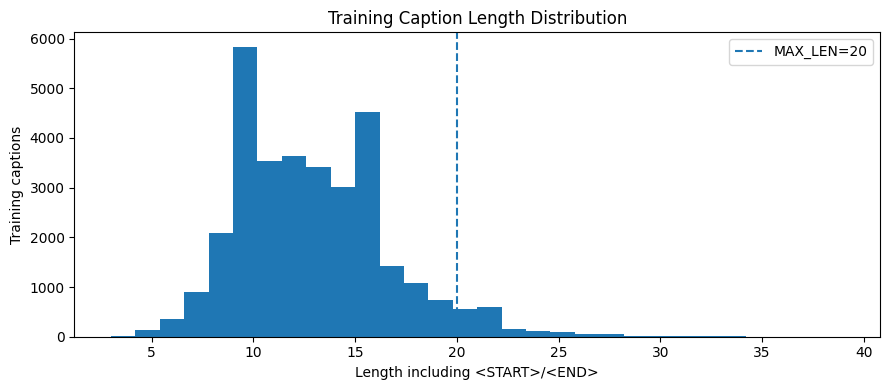

In [12]:
train_encoded_lengths = train_df["token_count"] + 2

percentile_len = int(
    math.ceil(
        np.percentile(
            train_encoded_lengths.to_numpy(),
            CFG.LEN_PERCENTILE,
        )
    )
)

MAX_LEN = min(
    max(percentile_len, CFG.MIN_MAX_LEN),
    CFG.HARD_MAX_LEN,
)

train_truncation_rate = float(
    (train_encoded_lengths > MAX_LEN).mean()
)

print(f"{CFG.LEN_PERCENTILE}th percentile:", percentile_len)
print("MAX_LEN:", MAX_LEN)
print("Train captions requiring truncation:", f"{100*train_truncation_rate:.2f}%")

plt.figure(figsize=(9, 4))
plt.hist(train_encoded_lengths, bins=30)
plt.axvline(MAX_LEN, linestyle="--", label=f"MAX_LEN={MAX_LEN}")
plt.xlabel("Length including <START>/<END>")
plt.ylabel("Training captions")
plt.title("Training Caption Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Encode captions while always preserving `<END>`

اگر کپشن بلند باشد، ابتدا فقط content tokenها truncate می‌شوند و سپس `<END>` اضافه می‌شود.

In [13]:
def encode_caption(tokens, max_len=MAX_LEN):
    content = tokens[:max_len - 2]

    ids = [
        START_ID,
        *[word2idx.get(token, UNK_ID) for token in content],
        END_ID,
    ]

    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))

    assert len(ids) == max_len
    assert ids[0] == START_ID
    assert END_ID in ids

    return ids

encoded_captions = np.stack(
    [
        encode_caption(tokens)
        for tokens in tqdm(df["tokens"], desc="Encoding captions")
    ]
).astype(np.int32)

assert encoded_captions.shape == (len(df), MAX_LEN)
assert np.all(encoded_captions[:, 0] == START_ID)
assert np.all((encoded_captions == END_ID).any(axis=1))

print("Encoded matrix shape:", encoded_captions.shape)

Encoding captions:   0%|          | 0/40455 [00:00<?, ?it/s]

Encoded matrix shape: (40455, 20)


## 14. Decode sanity check

In [14]:
def decode_ids(ids):
    words = []

    for token_id in ids:
        token_id = int(token_id)

        if token_id == PAD_ID:
            continue

        word = idx2word[token_id]
        words.append(word)

        if token_id == END_ID:
            break

    return " ".join(words)

indices = [0, len(df)//3, 2*len(df)//3]

for idx in indices:
    print("\nRAW    :", df.iloc[idx]["caption"])
    print("CLEAN  :", df.iloc[idx]["clean_caption"])
    print("DECODED:", decode_ids(encoded_captions[idx]))


RAW    : A child in a pink dress is climbing up a set of stairs in an entry way .
CLEAN  : a child in a pink dress is climbing up a set of stairs in an entry way
DECODED: <start> a child in a pink dress is climbing up a set of stairs in an <unk> way <end>

RAW    : A boy plays in the ocean with a boogie board .
CLEAN  : a boy plays in the ocean with a boogie board
DECODED: <start> a boy plays in the ocean with a boogie board <end>

RAW    : "Two figures stand in a snowy setting wearing white and hot pink outfits , gazing towards a mountain ."
CLEAN  : two figures stand in a snowy setting wearing white and hot pink outfits gazing towards a mountain
DECODED: <start> two <unk> stand in a snowy setting wearing white and hot pink outfits <unk> towards a mountain <end>


## 15. Image preprocessing compatible with pretrained ResNet50

صورت پروژه Normalization متناسب با مدل pretrained را الزام می‌کند.  
در اینجا transform رسمی `ResNet50_Weights.IMAGENET1K_V2` استفاده می‌شود.

In [15]:
RESNET_WEIGHTS = tvm.ResNet50_Weights.IMAGENET1K_V2
MODEL_IMAGE_TRANSFORM = RESNET_WEIGHTS.transforms()

print(MODEL_IMAGE_TRANSFORM)

TRANSFORM_METADATA = {
    "encoder": "resnet50",
    "weights": "IMAGENET1K_V2",
    "resize_size": 232,
    "crop_size": 224,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
}

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 16. Required 5×5 grid from a training batch

برای نمایش طبیعی تصویر، geometry همان Resize/CenterCrop مدل حفظ می‌شود ولی normalization فقط برای نمایش اعمال نمی‌شود.

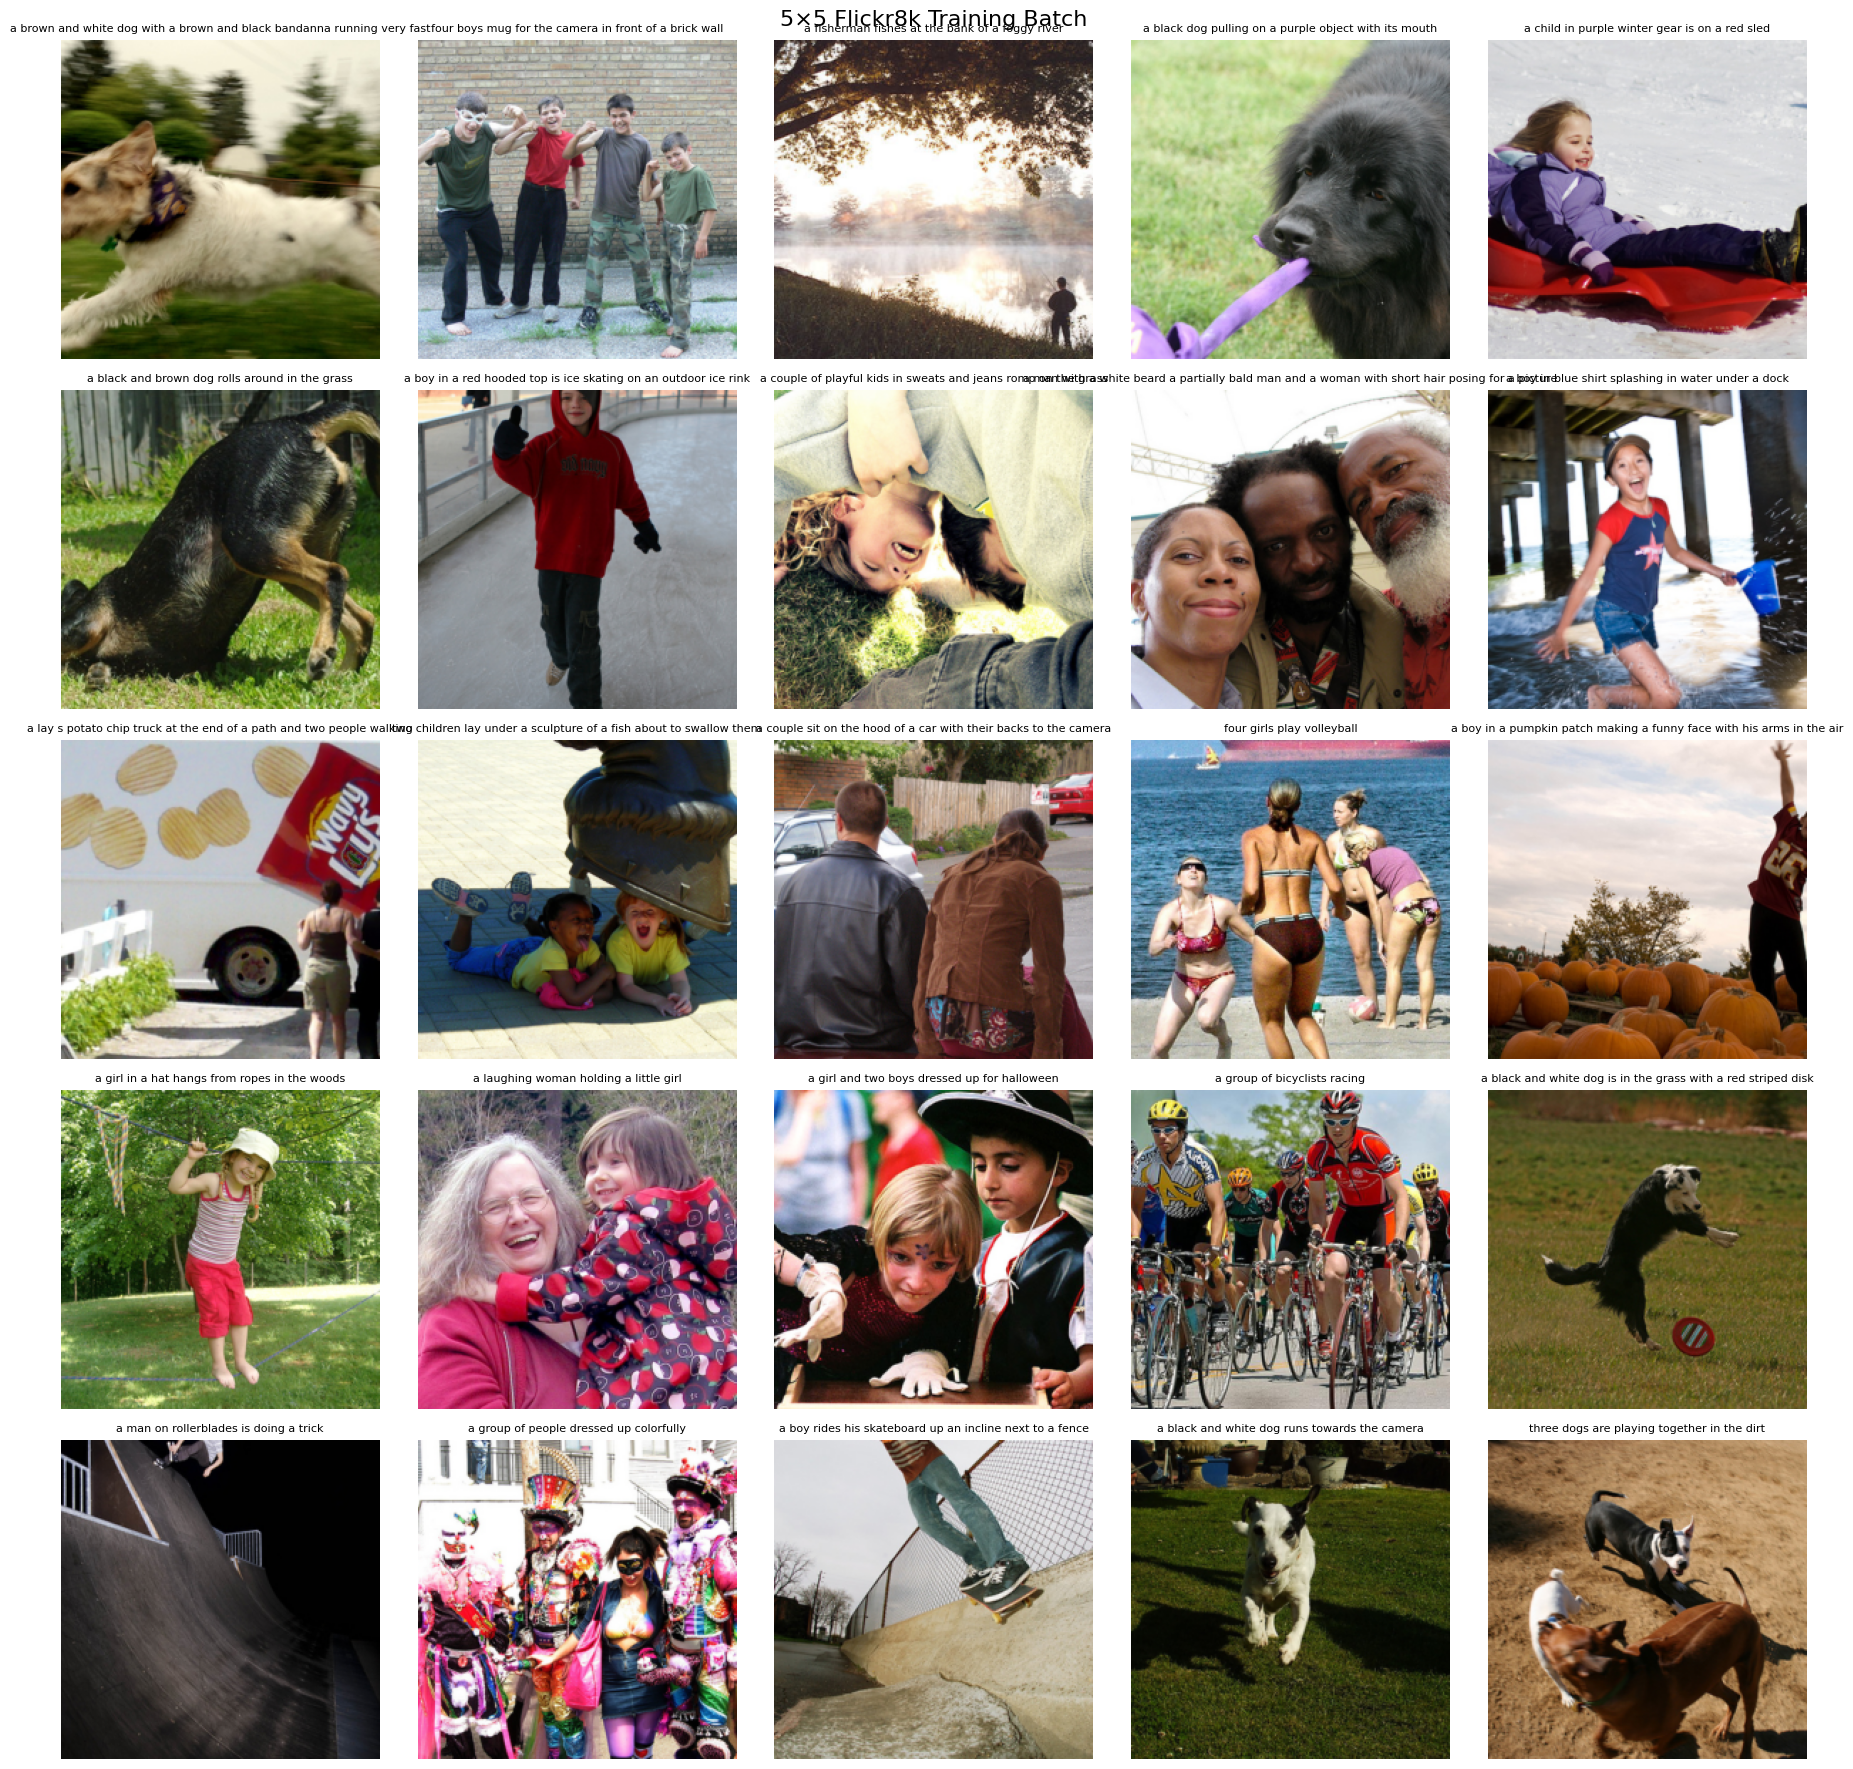

Saved: /kaggle/working/preprocessed/train_batch_grid_5x5.png


In [16]:
VISUAL_TRANSFORM = T.Compose([
    T.Resize(232),
    T.CenterCrop(224),
    T.ToTensor(),
])

class TrainingPreviewDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = (
            frame.sort_values(["image", "clean_caption"])
                 .groupby("image", as_index=False)
                 .first()
                 .reset_index(drop=True)
        )
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")
            tensor = self.transform(image)

        return tensor, row["clean_caption"], row["image"]

preview_ds = TrainingPreviewDataset(train_df, VISUAL_TRANSFORM)

preview_generator = torch.Generator()
preview_generator.manual_seed(CFG.SEED)

preview_loader = DataLoader(
    preview_ds,
    batch_size=25,
    shuffle=True,
    num_workers=0,
    generator=preview_generator,
)

images_batch, captions_batch, names_batch = next(iter(preview_loader))

fig, axes = plt.subplots(5, 5, figsize=(18, 18))

for i, ax in enumerate(axes.flat):
    image = images_batch[i].permute(1, 2, 0).numpy()
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(captions_batch[i], fontsize=8)
    ax.axis("off")

plt.suptitle("5×5 Flickr8k Training Batch", fontsize=16)
plt.tight_layout()

GRID_PATH = os.path.join(CFG.OUTPUT_DIR, "train_batch_grid_5x5.png")
plt.savefig(GRID_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", GRID_PATH)

# 17. Optional engineering step — cache frozen ResNet50 spatial features

این مرحله الزام صریح preprocessing نیست، اما برای ادامه پروژه بسیار مفید است:

```text
ResNet50 final feature map
(B, 2048, 7, 7)
       ↓
(B, 49, 2048)
```

- LSTM بعداً می‌تواند روی 49 token میانگین بگیرد.
- Transformer همان 49 token را برای Cross-Attention استفاده می‌کند.
- Attention Map مستقیماً به شبکه 7×7 برمی‌گردد.

In [17]:
class FrozenResNet50SpatialEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = tvm.resnet50(weights=RESNET_WEIGHTS)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        for p in self.backbone.parameters():
            p.requires_grad = False

        self.backbone.eval()

    def forward(self, images):
        x = self.backbone(images)      # (B, 2048, 7, 7)
        x = x.flatten(2)               # (B, 2048, 49)
        x = x.transpose(1, 2)          # (B, 49, 2048)
        return x


class UniqueImageDataset(Dataset):
    def __init__(self, image_names, path_map, transform):
        self.image_names = list(image_names)
        self.path_map = path_map
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        path = self.path_map[image_name]

        with Image.open(path) as image:
            image = image.convert("RGB")
            tensor = self.transform(image)

        return image_name, tensor


encoder = FrozenResNet50SpatialEncoder().to(DEVICE)
encoder.eval()

sample_names = sorted(df["image"].unique())[:2]
sample_loader = DataLoader(
    UniqueImageDataset(sample_names, image_path_map, MODEL_IMAGE_TRANSFORM),
    batch_size=2,
    shuffle=False,
    num_workers=0,
)

_, sample_images = next(iter(sample_loader))

with torch.inference_mode():
    sample_features = encoder(sample_images.to(DEVICE))

print("Feature shape:", tuple(sample_features.shape))
assert tuple(sample_features.shape[1:]) == (49, 2048)

del sample_images, sample_features

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


Feature shape: (2, 49, 2048)


## 18. Extract the spatial feature cache

In [18]:
def extract_feature_cache():
    image_names = sorted(df["image"].unique())

    dataset = UniqueImageDataset(
        image_names,
        image_path_map,
        MODEL_IMAGE_TRANSFORM,
    )

    loader = DataLoader(
        dataset,
        batch_size=CFG.FEATURE_BATCH_SIZE,
        shuffle=False,
        num_workers=CFG.FEATURE_NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        # Keep workers non-persistent so all file/process resources
        # are released immediately after feature extraction.
        persistent_workers=False,
    )

    np_dtype = np.float16 if CFG.FEATURE_DTYPE == "float16" else np.float32

    h5_path = os.path.join(CFG.OUTPUT_DIR, "features.h5")
    image_to_feature_idx = {}

    row = 0
    start = time.time()

    with h5py.File(h5_path, "w") as h5:
        ds = h5.create_dataset(
            "features",
            shape=(len(image_names), 49, 2048),
            dtype=np_dtype,
            chunks=(1, 49, 2048),
            compression="gzip",
            compression_opts=4,
        )

        for names, images in tqdm(loader, desc="Caching ResNet50 features"):
            images = images.to(DEVICE, non_blocking=True)

            with torch.inference_mode():
                features = encoder(images)

            features = (
                features.float()
                .cpu()
                .numpy()
                .astype(np_dtype, copy=False)
            )

            batch_size = features.shape[0]
            ds[row:row + batch_size] = features

            for offset, image_name in enumerate(names):
                image_to_feature_idx[str(image_name)] = row + offset

            row += batch_size

            del images, features

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        # Validate the cache while this writer owns the HDF5 file.
        assert row == len(image_names)
        assert ds.shape == (len(image_names), 49, 2048)
        h5.flush()

    elapsed_min = (time.time() - start) / 60.0

    return h5_path, image_to_feature_idx, elapsed_min


if CFG.EXTRACT_FEATURES:
    FEATURES_H5_PATH, image_to_feature_idx, extraction_minutes = extract_feature_cache()

    print("Feature cache:", FEATURES_H5_PATH)
    print("Size:", f"{os.path.getsize(FEATURES_H5_PATH)/1e6:.2f} MB")
    print("Extraction time:", f"{extraction_minutes:.2f} min")
else:
    FEATURES_H5_PATH = None
    image_to_feature_idx = {}
    extraction_minutes = None
    print("Feature caching disabled.")

Caching ResNet50 features:   0%|          | 0/127 [00:00<?, ?it/s]

Feature cache: /kaggle/working/preprocessed/features.h5
Size: 148.74 MB
Extraction time: 0.87 min


## 19. Attach feature indices to caption rows

In [19]:
if CFG.EXTRACT_FEATURES:
    df["feature_idx"] = df["image"].map(image_to_feature_idx)

    assert df["feature_idx"].notna().all()

    df["feature_idx"] = df["feature_idx"].astype(np.int32)
else:
    df["feature_idx"] = -1

## 20. Save all preprocessing artifacts

In [20]:
CAPTIONS_CSV_PATH = os.path.join(CFG.OUTPUT_DIR, "captions.csv")
TOKEN_IDS_PATH = os.path.join(CFG.OUTPUT_DIR, "token_ids.npy")
VOCAB_PATH = os.path.join(CFG.OUTPUT_DIR, "vocab.json")
SPLITS_PATH = os.path.join(CFG.OUTPUT_DIR, "splits.json")
TRANSFORM_PATH = os.path.join(CFG.OUTPUT_DIR, "transform_config.json")
FEATURE_INDEX_PATH = os.path.join(CFG.OUTPUT_DIR, "feature_index.json")

csv_df = df.drop(columns=["tokens"]).copy()
csv_df.insert(0, "row_id", np.arange(len(csv_df)))

csv_df.to_csv(CAPTIONS_CSV_PATH, index=False)
np.save(TOKEN_IDS_PATH, encoded_captions)

with open(VOCAB_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "word2idx": word2idx,
            "idx2word": idx2word,
            "built_from_split": "train",
            "min_word_freq": CFG.MIN_WORD_FREQ,
            "max_vocab_size": CFG.MAX_VOCAB_SIZE,
            "special_tokens": {
                "pad_token": "<pad>",
                "start_token": "<start>",
                "end_token": "<end>",
                "unk_token": "<unk>",
                "pad_id": PAD_ID,
                "start_id": START_ID,
                "end_id": END_ID,
                "unk_id": UNK_ID,
            },
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(SPLITS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "seed": CFG.SEED,
            "strategy": "image_level_random_split",
            "ratios": {
                "train": CFG.TRAIN_RATIO,
                "val": CFG.VAL_RATIO,
                "test": CFG.TEST_RATIO,
            },
            "train": sorted(train_images),
            "val": sorted(val_images),
            "test": sorted(test_images),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(TRANSFORM_PATH, "w", encoding="utf-8") as f:
    json.dump(TRANSFORM_METADATA, f, indent=2)

if CFG.EXTRACT_FEATURES:
    with open(FEATURE_INDEX_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {
                "id2idx": image_to_feature_idx,
                "num_images": len(image_to_feature_idx),
                "num_tokens": 49,
                "feature_dim": 2048,
                "dtype": CFG.FEATURE_DTYPE,
                "encoder": "resnet50",
                "weights": "IMAGENET1K_V2",
                "mode": "spatial",
            },
            f,
            ensure_ascii=False,
            indent=2,
        )

print("Saved captions, encoded tokens, vocabulary, split and transform metadata.")

Saved captions, encoded tokens, vocabulary, split and transform metadata.


## 21. Final integrity checks

In [21]:
assert csv_df["image_path"].notna().all()

assert train_images.isdisjoint(val_images)
assert train_images.isdisjoint(test_images)
assert val_images.isdisjoint(test_images)

assert encoded_captions.shape == (len(csv_df), MAX_LEN)
assert np.all(encoded_captions[:, 0] == START_ID)
assert np.all((encoded_captions == END_ID).any(axis=1))

assert np.array_equal(
    csv_df["row_id"].to_numpy(),
    np.arange(len(csv_df)),
)

if CFG.EXTRACT_FEATURES:
    # The HDF5 tensor shape was already validated and flushed inside
    # extract_feature_cache() while the writer safely owned the file.
    # Reopening it immediately can trigger an HDF5 file-lock race on Kaggle.
    assert os.path.exists(FEATURES_H5_PATH)
    assert os.path.getsize(FEATURES_H5_PATH) > 0

    assert csv_df["feature_idx"].between(
        0,
        csv_df["image"].nunique() - 1,
    ).all()

print("ALL FINAL INTEGRITY CHECKS PASSED.")

ALL FINAL INTEGRITY CHECKS PASSED.


## 22. Save preprocessing audit report

In [22]:
split_caption_counts = {
    split: int((csv_df["split"] == split).sum())
    for split in ["train", "val", "test"]
}

split_image_counts = {
    split: int(
        csv_df.loc[csv_df["split"] == split, "image"].nunique()
    )
    for split in ["train", "val", "test"]
}

audit_report = {
    "raw_caption_rows": int(len(raw_df)),
    "raw_unique_images": int(raw_df["image"].nunique()),
    "exact_duplicate_image_caption_pairs_retained": int(duplicate_pair_count),
    "missing_caption_rows_removed": int(missing_caption_rows),
    "corrupted_images_removed": int(len(bad_image_records)),
    "final_caption_rows": int(len(csv_df)),
    "final_unique_images": int(csv_df["image"].nunique()),
    "split_caption_counts": split_caption_counts,
    "split_image_counts": split_image_counts,
    "vocab_size": int(VOCAB_SIZE),
    "max_len": int(MAX_LEN),
    "train_truncation_rate": float(train_truncation_rate),
    "oov_rates": OOV_RATES,
    "feature_cache_enabled": bool(CFG.EXTRACT_FEATURES),
}

AUDIT_PATH = os.path.join(CFG.OUTPUT_DIR, "preprocessing_audit.json")

with open(AUDIT_PATH, "w", encoding="utf-8") as f:
    json.dump(audit_report, f, indent=2, ensure_ascii=False)

print(json.dumps(audit_report, indent=2, ensure_ascii=False))

{
  "raw_caption_rows": 40455,
  "raw_unique_images": 8091,
  "exact_duplicate_image_caption_pairs_retained": 10,
  "missing_caption_rows_removed": 0,
  "corrupted_images_removed": 0,
  "final_caption_rows": 40455,
  "final_unique_images": 8091,
  "split_caption_counts": {
    "train": 32360,
    "val": 4045,
    "test": 4050
  },
  "split_image_counts": {
    "train": 6472,
    "val": 809,
    "test": 810
  },
  "vocab_size": 2659,
  "max_len": 20,
  "train_truncation_rate": 0.03442521631644005,
  "oov_rates": {
    "train": 0.024178628935557916,
    "val": 0.029141417580172944,
    "test": 0.03089757811055648
  },
  "feature_cache_enabled": true
}


## 23. Save the project-wide manifest

In [23]:
manifest = {
    "artifact_version": 1,
    "project": "Image Captioning Final Project",
    "dataset": "Flickr8k",

    # These paths document the raw source used for this exact run.
    # Later notebooks should still be able to auto-discover raw images
    # by filename if Kaggle mounts the same dataset under a different path.
    "source_caption_file": str(CAPTION_FILE),
    "source_images_dir": str(IMAGES_DIR),

    "seed": CFG.SEED,

    "counts": {
        "captions": int(len(csv_df)),
        "unique_images": int(csv_df["image"].nunique()),
    },

    "split": {
        "strategy": "image_level_random_split",
        "ratios": {
            "train": CFG.TRAIN_RATIO,
            "val": CFG.VAL_RATIO,
            "test": CFG.TEST_RATIO,
        },
        "images": split_image_counts,
        "captions": split_caption_counts,
    },

    "text": {
        "cleaning": {
            "lowercase": True,
            "punctuation_removed": True,
            "digits_removed": False,
            "whitespace_normalized": True,
            "tokenizer": "whitespace_after_cleaning",
        },

        "vocabulary_built_from": "train",
        "vocab_size": int(VOCAB_SIZE),
        "min_word_freq": int(CFG.MIN_WORD_FREQ),
        "max_vocab_size": int(CFG.MAX_VOCAB_SIZE),

        "max_len": int(MAX_LEN),
        "max_len_built_from": "train",
        "length_percentile": int(CFG.LEN_PERCENTILE),

        "pad_id": PAD_ID,
        "start_id": START_ID,
        "end_id": END_ID,
        "unk_id": UNK_ID,
    },

    "image_transform": TRANSFORM_METADATA,

    "encoder_features": {
        "cached": bool(CFG.EXTRACT_FEATURES),
        "encoder": "resnet50",
        "weights": "IMAGENET1K_V2",
        "frozen": True,
        "spatial_tokens": 49,
        "feature_dim": 2048,
        "dtype": CFG.FEATURE_DTYPE if CFG.EXTRACT_FEATURES else None,
    },

    "files": {
        "captions_csv": "captions.csv",
        "token_ids": "token_ids.npy",
        "vocab": "vocab.json",
        "splits": "splits.json",
        "transform_config": "transform_config.json",
        "features_h5": "features.h5" if CFG.EXTRACT_FEATURES else None,
        "feature_index": "feature_index.json" if CFG.EXTRACT_FEATURES else None,
        "training_grid": "train_batch_grid_5x5.png",
        "audit": "preprocessing_audit.json",
    },
}

MANIFEST_PATH = os.path.join(CFG.OUTPUT_DIR, "manifest.json")

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print(json.dumps(manifest, indent=2, ensure_ascii=False))

{
  "artifact_version": 1,
  "project": "Image Captioning Final Project",
  "dataset": "Flickr8k",
  "source_caption_file": "/kaggle/input/datasets/adityajn105/flickr8k/captions.txt",
  "source_images_dir": "/kaggle/input/datasets/adityajn105/flickr8k/Images",
  "seed": 42,
  "counts": {
    "captions": 40455,
    "unique_images": 8091
  },
  "split": {
    "strategy": "image_level_random_split",
    "ratios": {
      "train": 0.8,
      "val": 0.1,
      "test": 0.1
    },
    "images": {
      "train": 6472,
      "val": 809,
      "test": 810
    },
    "captions": {
      "train": 32360,
      "val": 4045,
      "test": 4050
    }
  },
  "text": {
    "cleaning": {
      "lowercase": true,
      "punctuation_removed": true,
      "digits_removed": false,
      "whitespace_normalized": true,
      "tokenizer": "whitespace_after_cleaning"
    },
    "vocabulary_built_from": "train",
    "vocab_size": 2659,
    "min_word_freq": 5,
    "max_vocab_size": 10000,
    "max_len": 20,
    "m

## 24. Output structure

پس از اجرای موفق `Run All`، خروجی این مرحله باید تقریباً این ساختار را داشته باشد:

```text
/kaggle/working/preprocessed/
│
├── captions.csv
├── token_ids.npy
├── vocab.json
├── splits.json
├── transform_config.json
├── manifest.json
├── preprocessing_audit.json
├── train_batch_grid_5x5.png
│
├── features.h5
└── feature_index.json
```

### قانون پروژه از اینجا به بعد

Notebookهای LSTM، Transformer و Prompt-Guided **نباید دوباره**:
- split بسازند،
- vocabulary بسازند،
- MAX_LEN تعیین کنند،
- caption cleaning متفاوت اعمال کنند.

همه باید همین artifactها را بخوانند.

In [24]:
output_files = sorted(
    p
    for p in Path(CFG.OUTPUT_DIR).iterdir()
    if p.is_file()
)

total_bytes = sum(
    p.stat().st_size
    for p in output_files
)

print("Generated preprocessing files:\n")

for p in output_files:
    print(
        f"{p.name:30s} "
        f"{p.stat().st_size / 1e6:9.2f} MB"
    )

print(
    f"\nTotal output size: "
    f"{total_bytes / 1e9:.3f} GB"
)

print("\nNotebook 01 completed successfully.")

Generated preprocessing files:

captions.csv                        9.39 MB
feature_index.json                  0.31 MB
features.h5                       148.74 MB
manifest.json                       0.00 MB
preprocessing_audit.json            0.00 MB
splits.json                         0.27 MB
token_ids.npy                       3.24 MB
train_batch_grid_5x5.png            9.39 MB
transform_config.json               0.00 MB
vocab.json                          0.09 MB

Total output size: 0.171 GB

Notebook 01 completed successfully.


# 25. What should be reported from this Notebook?

برای گزارش پروژه، از اجرای واقعی این Notebook موارد زیر را ثبت کن:

- نام دیتاست: Flickr8k
- تعداد نهایی تصاویر و کپشن‌ها
- نسبت و تعداد Train / Validation / Test
- Random Seed
- مراحل cleaning متن
- Special Tokens
- Vocabulary Size
- MAX_LEN
- ResNet50 preprocessing / normalization
- تصویر گرید 5×5
- در صورت استفاده از feature cache: شکل هر feature یعنی `49×2048`

اعداد را از خروجی واقعی Notebook گزارش کن و از نوشتن عدد حدسی خودداری کن.